In [167]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.svm import SVC
%matplotlib inline

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [168]:
prima_df = pd.read_csv("diabetes.csv")

#### Eye ball the imported dataset

In [169]:
prima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Check data types and info of dataset

In [170]:
prima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### Check dimension of dataset

In [171]:
prima_df.shape

(768, 9)

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

In [172]:
prima_df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

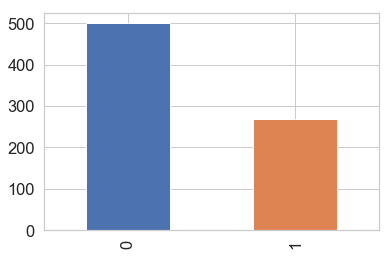

In [173]:
prima_df['Outcome'].value_counts().plot(kind = 'bar')

##### Out of  768 data points, 500 are labeled as 0 and 268 as 1. Outcome 0 means No diabetes, outcome 1 means diabetes

### Check data distribution using summary statistics and provide your findings(2 Marks)

In [174]:
prima_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


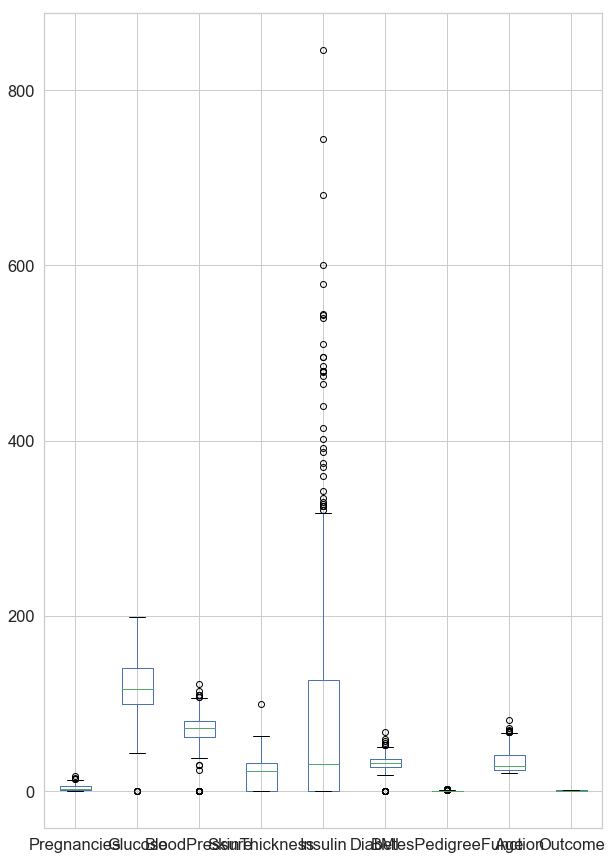

In [175]:
prima_df.boxplot(figsize=(10,15))

#### 'Insulin' feature has the most Outliers, followed by 'BloodPressure','BMI' and 'Age'

### Do correlation analysis and bivariate viualization with Insights(1 Marks)

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value 

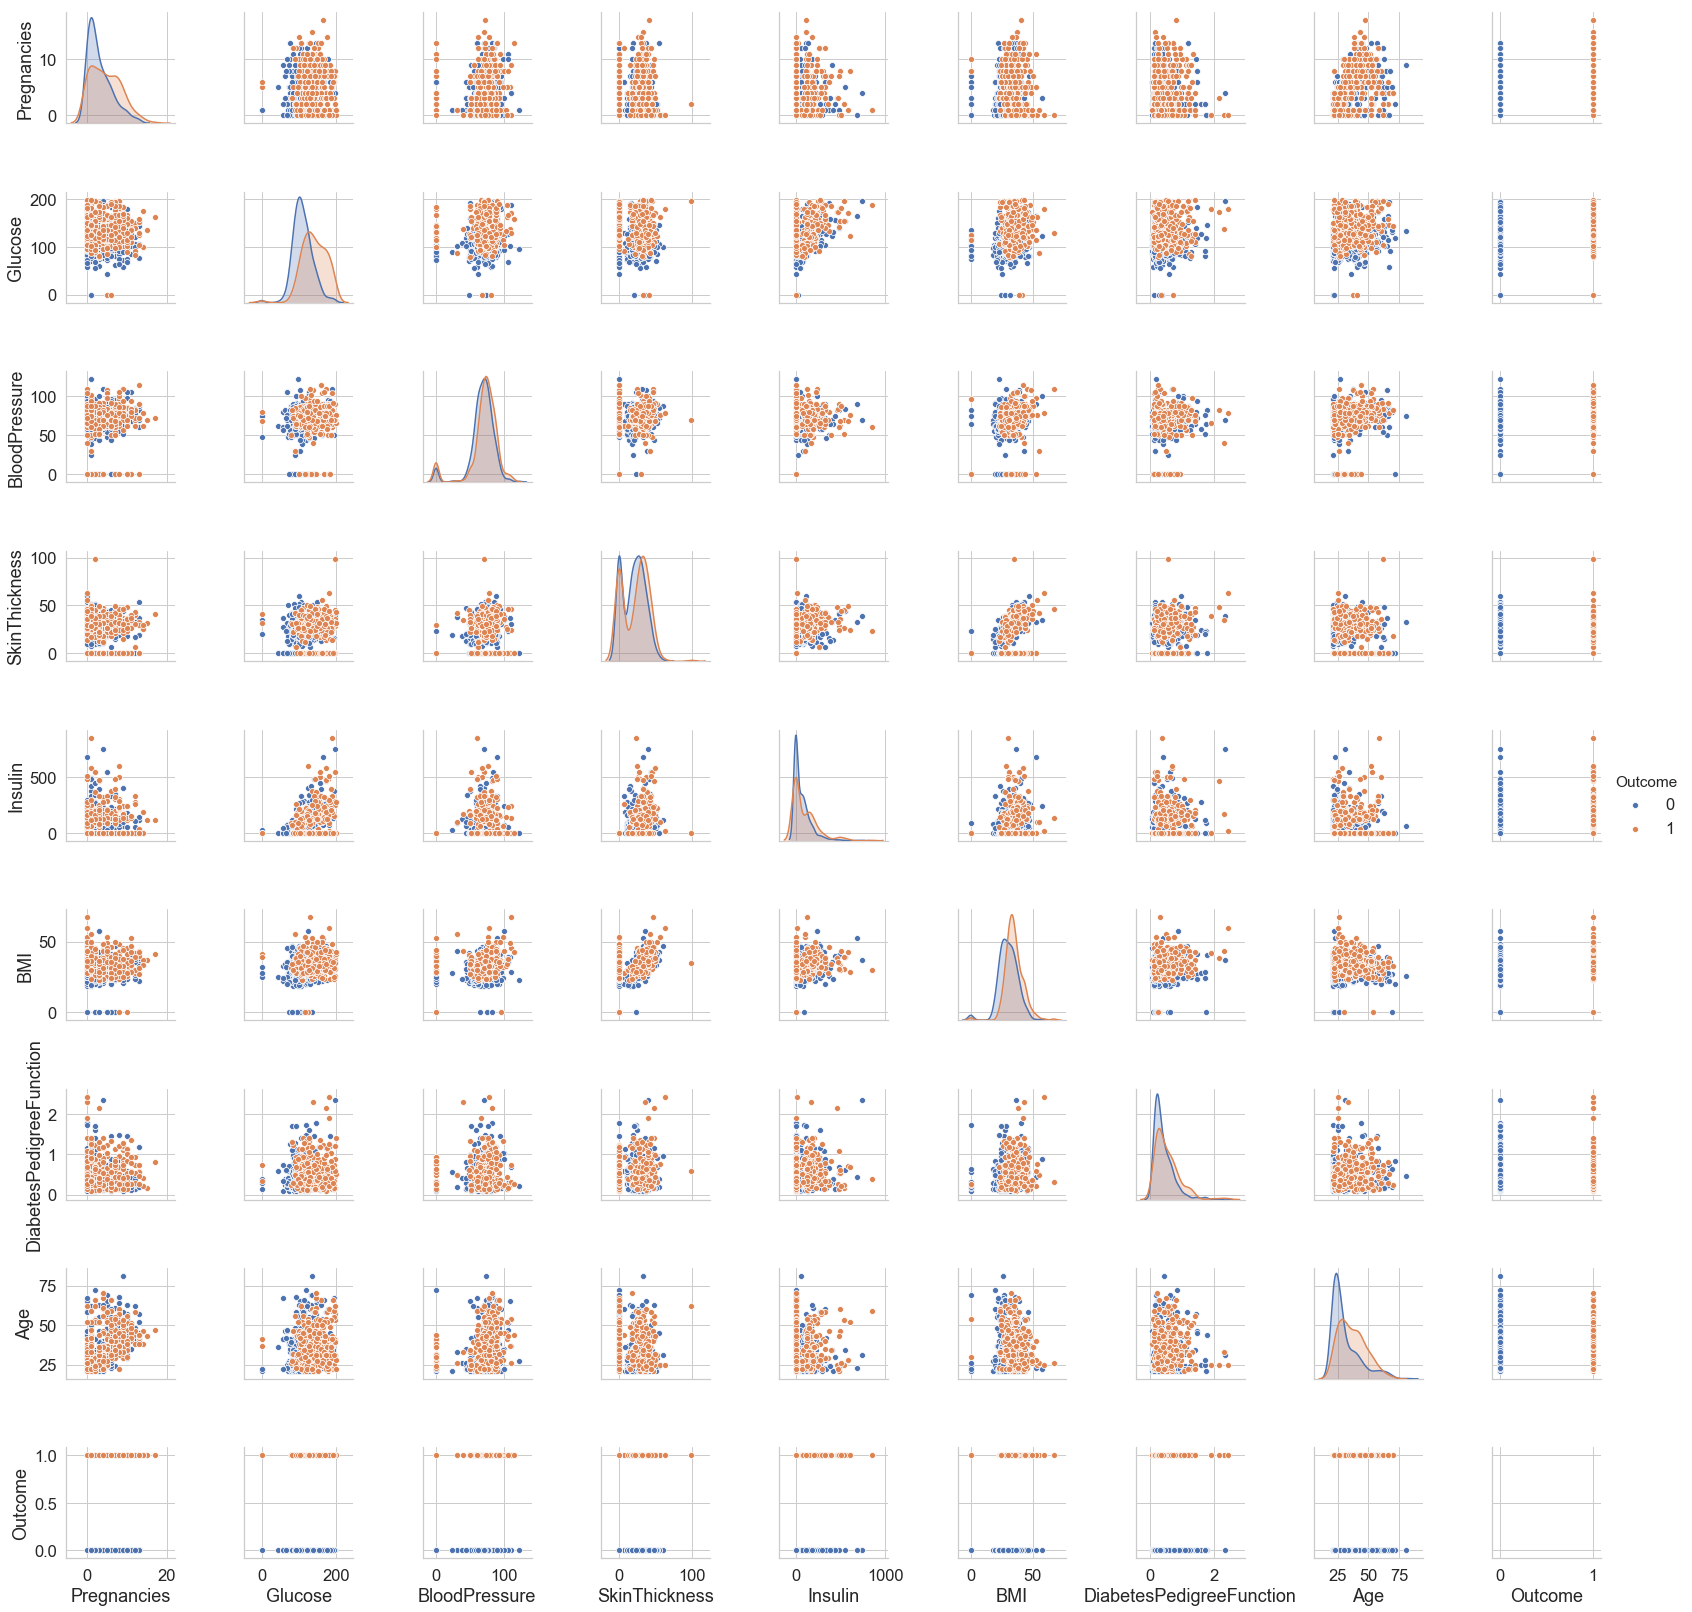

In [176]:
import seaborn as sns
# Pairplot using sns
sns.pairplot(prima_df, diag_kind = "kde", hue = "Outcome")

In [177]:
corr_data = prima_df.corr()

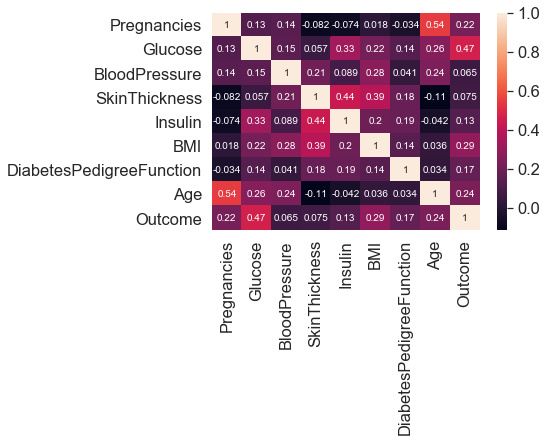

In [178]:
sns.heatmap(corr_data, annot=True)

#### InSights:
#####  * None of the features has correlation > 0.9

#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [179]:
y = prima_df["Outcome"]
X = prima_df.drop(["Outcome"], axis=1)

In [180]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=40, stratify=y)

### Train Support Vector Machine Model(1 Marks)

In [181]:
from sklearn.svm import SVC

# Building a Support Vector Machine on train data
svc_model = SVC(C= .1, kernel='linear', gamma= 1)
svc_model.fit(X_train, y_train)

# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.7895716945996276
0.7619047619047619


### Scale the data points using MinMaxScaler ( 1 Marks)

In [182]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)


### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [183]:
# Building a Support Vector Machine on train data
svc_model_scaled = SVC(C= .1, kernel='linear', gamma= 1)
svc_model_scaled.fit(X_train_scaled, y_train)

# check the accuracy on the training set
print(svc_model_scaled.score(X_train_scaled, y_train))
print(svc_model_scaled.score(X_test_scaled, y_test))

0.6610800744878957
0.683982683982684


#we can try increasing either C or gamma to fit a more complex model.

### Try improving the model accuracy using C=1000 (1 Marks)

In [184]:
svc_model = SVC(C=1000, kernel='linear', gamma=1)
svc_model.fit(X_train_scaled, y_train)

# check the accuracy on the training set
print(svc_model.score(X_train_scaled, y_train))
print(svc_model.score(X_test_scaled, y_test))

0.7988826815642458
0.7272727272727273


### Here, increasing C allows us to improve the model, resulting in 0.79/0.72 accuracy.
##### * Increasing the C value to 1000 improved the accuracy 

### Let's try to explore different Kernel and C (Bonus for practice)

In [185]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [186]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [187]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [188]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [189]:
gs.best_estimator_

SVC(C=3.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [191]:
gs.best_score_ 

0.7877094972067039